In [1]:
import gc
import json
import pickle
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

from sklearn.cluster import (
    AgglomerativeClustering, DBSCAN, KMeans, MiniBatchKMeans,
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    calinski_harabasz_score, davies_bouldin_score,
    silhouette_samples, silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import mlflow
import mlflow.sklearn

try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "hdbscan"])
    import hdbscan
    HAS_HDBSCAN = True

try:
    from kneed import KneeLocator
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kneed"])
    from kneed import KneeLocator

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Contrainte métier : minimum 4 clusters, maximum 8
K_MIN   = 4
K_MAX   = 8
K_RANGE = range(K_MIN, K_MAX + 1)

# Tailles sous-échantillons
N_SIL     = 15_000   # silhouette
N_SLOW    = 20_000   # CAH O(n²)
N_DBSCAN  = 15_000
N_HDBSCAN = 15_000

for d in ["models", "figures", "reports"]:
    Path(d).mkdir(exist_ok=True)

print("✅ Imports OK")
print(f"   K_RANGE : {K_MIN} à {K_MAX}")

✅ Imports OK
   K_RANGE : 4 à 8


In [2]:
%%time
# ─── Chargement de la base finale ────────────────────────────
# Base.csv = df_client sauvegardé à la fin du notebook d'analyse
# 93 358 clients × 48 variables
# Clients filtrés : uniquement ceux ayant au moins une livraison

df_client = pd.read_csv("Base.csv", low_memory=False)

print(f"✅ Base chargée : {df_client.shape}")
print(f"   Clients : {df_client['customer_unique_id'].nunique():,}")
print(f"   Variables : {df_client.shape[1]}")
print(f"\nColonnes disponibles :\n{df_client.columns.tolist()}")

✅ Base chargée : (93358, 47)
   Clients : 93,358
   Variables : 47

Colonnes disponibles :
['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'avg_delivery_days', 'late_delivery_rate', 'avg_delivery_delta', 'preferred_payment', 'avg_installments', 'product_diversity', 'avg_order_value', 'avg_freight_value', 'preferred_category', 'avg_lat', 'avg_lng', 'avg_freight_ratio', 'std_freight_ratio', 'review_participation_rate', 'cancellation_rate', 'avg_review_score_full', 'has_full_review', 'avg_review_score_available', 'has_available_review', 'has_delivered_orders', 'has_cancelled_orders', 'avg_basket_size', 'first_purchase_category', 'first_purchase_value', 'inter_purchase_time', 'dissatisfaction_rate_proxy', 'avg_seller_rating', 'payment_type_diversity', "spend_('price', 'electronics')", "spend_('price', 'health_beauty')", "spend_('price', 'home')", "spend_('price', 'other')", "spend_('price', 'sports_leisure')", 'dist_sao_paulo', 'recency_ratio', 'CLV_estimate', 'is_repeat_custome

In [3]:
# ════════════════════════════════════════════════════════════
# STRATÉGIE DE SÉLECTION
#
# Variables EXCLUES (redondances confirmées par la corrélation) :
#   avg_order_value       → r=0.978 avec Monetary
#   first_purchase_value  → r=0.982 avec Monetary (r=1.0 one-timers)
#   dissatisfaction_rate  → r=-0.808 avec avg_review_score_available
#   review_participation  → r=0.994 avec has_full_review
#   has_full_review       → redondant avec review_participation_rate
#   cancellation_rate     → r=0.990 avec has_cancelled_orders
#   never_delivered       → r=-1.0 avec has_delivery_info
#   Monetary (brut)       → on garde Monetary_log
#   CLV_estimate          → dérivé de Monetary × Frequency (post-hoc)
#   Frequency             → 97% = 1, quasi-constante
#   has_delivery          → quasi-constant (tous livrés)
#   has_available_review  → quasi-constant
#   has_delivered_orders  → quasi-constant
#   has_review            → quasi-constant
#   has_delivery_info     → quasi-constant (r=-1 avec never_delivered)
#
# Variables ACTIVES : 15 variables décorrélées par dimension métier
# ════════════════════════════════════════════════════════════

FEATURES_ACTIVE = [
    # ── Axe Récence ───────────────────────────────────────────
    "Recency",                       # jours depuis dernier achat

    # ── Axe Valeur économique ─────────────────────────────────
    "Monetary",                  # valeur totale (log-transformée)
    "avg_installments",              # engagement crédit (nb versements)

    # ── Axe Expérience satisfaction ───────────────────────────
    "avg_review_score_available",    # note moyenne (1–5)
    "late_delivery_rate",            # taux de livraisons tardives

    # ── Axe Logistique ────────────────────────────────────────
    "avg_delivery_days",             # délai moyen de livraison
    "avg_delivery_delta",            # avance/retard sur estimation
    "avg_freight_ratio",             # part des frais de port (proxy géo)

    # ── Axe Diversité comportementale ────────────────────────
    "avg_basket_size",               # taille moyenne du panier
   # "payment_type_diversity",        # diversité des modes de paiement

    # ── Axe Géographique ─────────────────────────────────────
    "dist_sao_paulo",                # distance à São Paulo (km)

    # ── Axe Temporel ─────────────────────────────────────────
    "most_frequent_purchase_hour",   # heure d'achat habituelle
    "most_frequent_purchase_day",    # jour d'achat habituel

    # ── Axe Catégorie produit (spend par famille) ────────────
    "spend_('price', 'health_beauty')",
    "spend_('price', 'home')",
]

# Variables SUPPLÉMENTAIRES (illustratives — non actives dans l'ACP)
FEATURES_SUPPLEMENTARY = [
    "Frequency",              # quasi-constante (97% = 1)
    "CLV_estimate",           # post-hoc uniquement
    "Monetary",               # remplacé par Monetary_log
    "avg_order_value",        # r=0.978 avec Monetary
    "first_purchase_value",   # r=0.982 avec Monetary
    "avg_review_score_full",  # redondant avec avg_review_score_available
    "dissatisfaction_rate_proxy",  # r=-0.808 avec review_score
    "review_participation_rate",   # r=0.994 avec has_full_review
    "cancellation_rate",           # r=0.990 avec has_cancelled_orders
    "inter_purchase_time",         # non défini pour 97% one-timers
    "avg_seller_rating",           # trop nombreux NA imputés
]

print(f"Variables ACTIVES    : {len(FEATURES_ACTIVE)}")
for v in FEATURES_ACTIVE:
    if v in df_client.columns:
        std = df_client[v].std()
        print(f"  ✔ {v:<45} std={std:.3f}")
    else:
        print(f"  ❌ {v}  ← ABSENTE de la base")

missing_active = [v for v in FEATURES_ACTIVE if v not in df_client.columns]
if missing_active:
    print(f"\n⚠️  Variables manquantes : {missing_active}")
    print("   Adaptez FEATURES_ACTIVE en conséquence")
else:
    print(f"\n✅ Toutes les variables actives sont disponibles")

Variables ACTIVES    : 14
  ✔ Recency                                       std=152.592
  ✔ Monetary                                      std=226.314
  ✔ avg_installments                              std=2.691
  ✔ avg_review_score_available                    std=1.278
  ✔ late_delivery_rate                            std=0.272
  ✔ avg_delivery_days                             std=9.552
  ✔ avg_delivery_delta                            std=10.140
  ✔ avg_freight_ratio                             std=0.125
  ✔ avg_basket_size                               std=0.527
  ✔ dist_sao_paulo                                std=604.739
  ✔ most_frequent_purchase_hour                   std=1.108
  ✔ most_frequent_purchase_day                    std=0.507
  ✔ spend_('price', 'health_beauty')              std=88.936
  ✔ spend_('price', 'home')                       std=67.217

✅ Toutes les variables actives sont disponibles


In [4]:
# ── Vérification que les variables actives sont bien décorrélées ──
X_check = df_client[FEATURES_ACTIVE].fillna(0).astype(float)
corr    = X_check.corr()

print("=== Corrélations > 0.70 entre variables actives ===")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = abs(corr.iloc[i, j])
        if r > 0.70:
            print(f"  ⚠️  {corr.columns[i]:<45} ↔ {corr.columns[j]:<45}  r={r:.3f}")
            found = True
if not found:
    print("  ✅ Aucune corrélation > 0.70 — excellent pour l'ACP")

print(f"\n=== Variance (objectif : std > 0.10 avant normalisation) ===")
for feat in FEATURES_ACTIVE:
    std  = df_client[feat].std()
    flag = "  ⚠️  FAIBLE — envisager suppression" if std < 0.05 else ""
    print(f"  {feat:<45} std={std:.4f}{flag}")

del X_check; gc.collect()

=== Corrélations > 0.70 entre variables actives ===
  ✅ Aucune corrélation > 0.70 — excellent pour l'ACP

=== Variance (objectif : std > 0.10 avant normalisation) ===
  Recency                                       std=152.5917
  Monetary                                      std=226.3140
  avg_installments                              std=2.6914
  avg_review_score_available                    std=1.2781
  late_delivery_rate                            std=0.2721
  avg_delivery_days                             std=9.5517
  avg_delivery_delta                            std=10.1405
  avg_freight_ratio                             std=0.1249
  avg_basket_size                               std=0.5271
  dist_sao_paulo                                std=604.7388
  most_frequent_purchase_hour                   std=1.1080
  most_frequent_purchase_day                    std=0.5067
  spend_('price', 'health_beauty')              std=88.9359
  spend_('price', 'home')                       std=67.216

60

In [5]:
%%time
# ── Winsorisation préalable (cap 99e centile) ────────────────
def cap_outliers(df, cols, q=0.99):
    df = df.copy()
    for col in cols:
        df[col] = df[col].clip(
            lower=df[col].quantile(1 - q),
            upper=df[col].quantile(q)
        )
    return df


# Appliquer le cap uniquement sur les variables actives continues
X_raw    = cap_outliers(df_client, FEATURES_ACTIVE)[FEATURES_ACTIVE]
X_raw    = X_raw.fillna(0).astype("float32")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype("float32")

print(f"✅ X_scaled shape : {X_scaled.shape}")
print(f"   Mémoire : {X_scaled.nbytes / 1e6:.1f} Mo")

print(f"\nÉcart-types post-StandardScaler (tous ≈ 1.0) :")
stds = X_scaled.std(axis=0)
for feat, std in zip(FEATURES_ACTIVE, stds):
    flag = "  ⚠️  ANORMAL" if std < 0.5 or std > 1.5 else ""
    print(f"  {feat:<45} std={std:.3f}{flag}")

gc.collect()

✅ X_scaled shape : (93358, 14)
   Mémoire : 5.2 Mo

Écart-types post-StandardScaler (tous ≈ 1.0) :
  Recency                                       std=1.000
  Monetary                                      std=1.000
  avg_installments                              std=1.000
  avg_review_score_available                    std=1.000
  late_delivery_rate                            std=1.000
  avg_delivery_days                             std=1.000
  avg_delivery_delta                            std=1.000
  avg_freight_ratio                             std=1.000
  avg_basket_size                               std=1.000
  dist_sao_paulo                                std=1.000
  most_frequent_purchase_hour                   std=1.000
  most_frequent_purchase_day                    std=1.000
  spend_('price', 'health_beauty')              std=1.000
  spend_('price', 'home')                       std=1.000
CPU times: total: 359 ms
Wall time: 362 ms


0

In [6]:
%%time
# ── ACP complète sans whitening pour comprendre la structure ─
pca_diag    = PCA(n_components=len(FEATURES_ACTIVE), random_state=RANDOM_STATE)
pca_diag.fit(X_scaled)
cumvar_diag = np.cumsum(pca_diag.explained_variance_ratio_)

print("=== Variance expliquée par composante ===")
for i, (ev, cv) in enumerate(zip(pca_diag.explained_variance_ratio_, cumvar_diag)):
    bar  = "█" * int(ev * 50)
    mark = " ← PC1" if i == 0 else ""
    print(f"  PC{i+1:2d} : {ev:.3f}  cumulée={cv:.3f}  {bar}{mark}")

pc1 = pca_diag.explained_variance_ratio_[0]
print(f"\nPC1 domine à : {pc1*100:.1f}%")
if pc1 < 0.25:
    print("  ✅ Excellente répartition")
elif pc1 < 0.35:
    print("  ✅ Bonne répartition — whitening recommandé")
elif pc1 < 0.50:
    print("  ⚠️  Répartition modérée — whitening obligatoire")
else:
    print("  ❌ PC1 > 50% — revoir la sélection de variables")

print()
for s in [0.70, 0.80, 0.85, 0.90]:
    n = int(np.argmax(cumvar_diag >= s)) + 1
    print(f"  {s*100:.0f}% variance → {n} composantes")

=== Variance expliquée par composante ===
  PC 1 : 0.175  cumulée=0.175  ████████ ← PC1
  PC 2 : 0.142  cumulée=0.317  ███████
  PC 3 : 0.115  cumulée=0.432  █████
  PC 4 : 0.093  cumulée=0.525  ████
  PC 5 : 0.089  cumulée=0.614  ████
  PC 6 : 0.072  cumulée=0.686  ███
  PC 7 : 0.066  cumulée=0.752  ███
  PC 8 : 0.052  cumulée=0.804  ██
  PC 9 : 0.050  cumulée=0.854  ██
  PC10 : 0.048  cumulée=0.902  ██
  PC11 : 0.027  cumulée=0.929  █
  PC12 : 0.026  cumulée=0.956  █
  PC13 : 0.025  cumulée=0.981  █
  PC14 : 0.019  cumulée=1.000  

PC1 domine à : 17.5%
  ✅ Excellente répartition

  70% variance → 7 composantes
  80% variance → 8 composantes
  85% variance → 9 composantes
  90% variance → 10 composantes
CPU times: total: 78.1 ms
Wall time: 66.9 ms


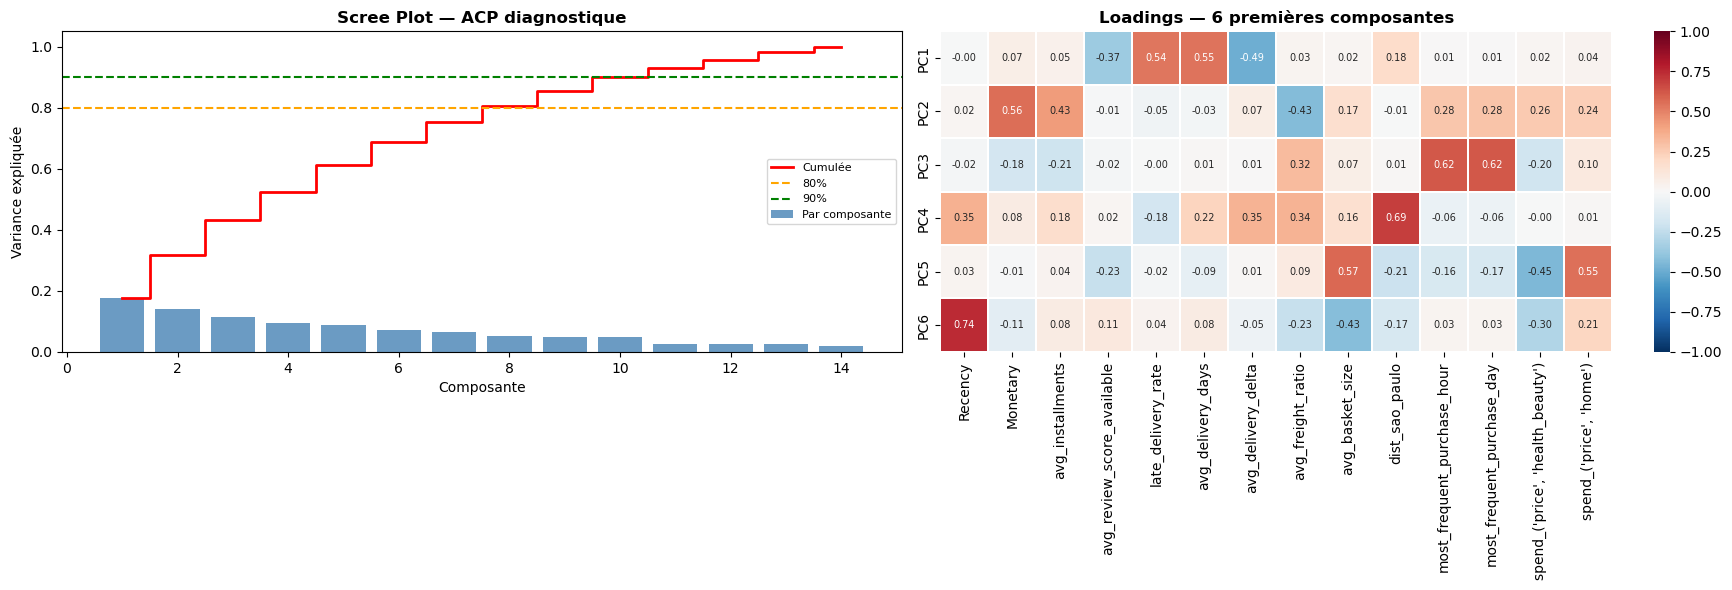


=== Interprétation des axes (|loading| > 0.30) ===

PC1 :
  + avg_delivery_days                             (+0.545)
  + late_delivery_rate                            (+0.537)
  - avg_delivery_delta                            (-0.486)
  - avg_review_score_available                    (-0.367)

PC2 :
  + Monetary                                      (+0.555)
  - avg_freight_ratio                             (-0.432)
  + avg_installments                              (+0.428)

PC3 :
  + most_frequent_purchase_hour                   (+0.620)
  + most_frequent_purchase_day                    (+0.619)
  + avg_freight_ratio                             (+0.319)

PC4 :
  + dist_sao_paulo                                (+0.693)
  + Recency                                       (+0.352)
  + avg_delivery_delta                            (+0.349)
  + avg_freight_ratio                             (+0.344)

PC5 :
  + avg_basket_size                               (+0.574)
  + spend_('price', 'home') 

In [7]:
# ── Heatmap des loadings ──────────────────────────────────────
n_pc = min(6, len(FEATURES_ACTIVE))
loadings_df = pd.DataFrame(
    pca_diag.components_[:n_pc],
    columns=FEATURES_ACTIVE,
    index=[f"PC{i+1}" for i in range(n_pc)]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scree plot
axes[0].bar(range(1, len(pca_diag.explained_variance_ratio_)+1),
            pca_diag.explained_variance_ratio_,
            color="steelblue", alpha=0.8, label="Par composante")
axes[0].step(range(1, len(cumvar_diag)+1), cumvar_diag,
             where="mid", color="red", lw=2, label="Cumulée")
axes[0].axhline(0.80, color="orange", ls="--", lw=1.5, label="80%")
axes[0].axhline(0.90, color="green",  ls="--", lw=1.5, label="90%")
axes[0].set_xlabel("Composante"); axes[0].set_ylabel("Variance expliquée")
axes[0].set_title("Scree Plot — ACP diagnostique", fontweight="bold")
axes[0].legend(fontsize=8)

# Heatmap loadings
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, lw=0.3, ax=axes[1], annot_kws={"size": 7})
axes[1].set_title(f"Loadings — {n_pc} premières composantes", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/01_acp_diagnostic.png", bbox_inches="tight", dpi=100)
plt.show(); plt.close()

# Interprétation des axes
print("\n=== Interprétation des axes (|loading| > 0.30) ===")
for pc in loadings_df.index:
    row = loadings_df.loc[pc]
    dom = row[row.abs() > 0.30].sort_values(key=abs, ascending=False)
    if len(dom) > 0:
        print(f"\n{pc} :")
        for feat, val in dom.items():
            print(f"  {'+'if val>0 else '-'} {feat:<45} ({val:+.3f})")

In [8]:
%%time
# ════════════════════════════════════════════════════════════
# ✏️  AJUSTEZ N_COMP selon votre scree plot
#     Règle : coude OU premier k tel que cumvar >= 85%
#     Avec 15 variables décorrélées → attendez 7 à 9 composantes
#     Commencez par N_COMP=7, ajustez selon la silhouette
# ════════════════════════════════════════════════════════════
N_COMP = 14    # ← modifiez ici

pca_final    = PCA(n_components=N_COMP, whiten=True, random_state=RANDOM_STATE)
X_pca        = pca_final.fit_transform(X_scaled)
cumvar_final = np.cumsum(pca_final.explained_variance_ratio_)

# PCA 2D pour visualisation (sans whitening pour lisibilité)
pca_2d   = PCA(n_components=2, whiten=False, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"N_COMP = {N_COMP} → variance retenue : {cumvar_final[-1]:.1%}")
print(f"X_pca shape  : {X_pca.shape}")
print(f"X_pca_2d shape : {X_pca_2d.shape}")

# Vérification que les axes sont bien multi-variables
loadings_final = pd.DataFrame(
    pca_diag.components_[:N_COMP],
    columns=FEATURES_ACTIVE,
    index=[f"PC{i+1}" for i in range(N_COMP)]
)
print("\n=== Axes retenus (|loading| > 0.30) ===")
for pc in loadings_final.index:
    row  = loadings_final.loc[pc]
    dom  = row[row.abs() > 0.30].sort_values(key=abs, ascending=False)
    mono = "  ⚠️  MONO-VARIABLE" if len(dom) == 1 else "  ✅"
    vars_str = ", ".join([f"{f}({v:+.2f})" for f, v in dom.items()])
    print(f"  {pc} : {vars_str}{mono}")

gc.collect()

N_COMP = 14 → variance retenue : 100.0%
X_pca shape  : (93358, 14)
X_pca_2d shape : (93358, 2)

=== Axes retenus (|loading| > 0.30) ===
  PC1 : avg_delivery_days(+0.55), late_delivery_rate(+0.54), avg_delivery_delta(-0.49), avg_review_score_available(-0.37)  ✅
  PC2 : Monetary(+0.56), avg_freight_ratio(-0.43), avg_installments(+0.43)  ✅
  PC3 : most_frequent_purchase_hour(+0.62), most_frequent_purchase_day(+0.62), avg_freight_ratio(+0.32)  ✅
  PC4 : dist_sao_paulo(+0.69), Recency(+0.35), avg_delivery_delta(+0.35), avg_freight_ratio(+0.34)  ✅
  PC5 : avg_basket_size(+0.57), spend_('price', 'home')(+0.55), spend_('price', 'health_beauty')(-0.45)  ✅
  PC6 : Recency(+0.74), avg_basket_size(-0.43), spend_('price', 'health_beauty')(-0.30)  ✅
  PC7 : Recency(+0.52), avg_basket_size(+0.39), spend_('price', 'health_beauty')(+0.39), spend_('price', 'home')(-0.38), avg_review_score_available(-0.37)  ✅
  PC8 : spend_('price', 'health_beauty')(+0.51), spend_('price', 'home')(+0.50), avg_review_scor

0

In [9]:
def evaluate_clustering(X, labels):
    """Silhouette cappé N_SIL, DB, Calinski. Ignore bruit=-1."""
    mask = labels != -1
    nc   = len(set(labels[mask]))
    nn   = int((~mask).sum())
    if nc < 2:
        return {"n_clusters": nc, "n_noise": nn,
                "silhouette": np.nan, "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan}
    Xm, lm = X[mask], labels[mask]
    if len(Xm) > N_SIL:
        idx = np.random.choice(len(Xm), N_SIL, replace=False)
        sil = silhouette_score(Xm[idx], lm[idx])
    else:
        sil = silhouette_score(Xm, lm)
    return {
        "n_clusters":        nc,
        "n_noise":           nn,
        "silhouette":        round(float(sil), 4),
        "davies_bouldin":    round(float(davies_bouldin_score(Xm, lm)), 4),
        "calinski_harabasz": round(float(calinski_harabasz_score(Xm, lm)), 2),
    }


def plot_pca_clusters(X_2d, labels, title, save=None):
    unique  = sorted(set(labels))
    palette = plt.cm.get_cmap("tab10", max(len(unique), 10))
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, lab in enumerate(unique):
        m     = labels == lab
        color = "lightgrey" if lab == -1 else palette(i)
        lbl   = f"Bruit ({m.sum():,})" if lab==-1 else f"C{lab} ({m.sum():,})"
        ax.scatter(X_2d[m, 0], X_2d[m, 1], c=[color], s=5, alpha=0.5, label=lbl)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, markerscale=2)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight", dpi=100)
    plt.show(); plt.close()


def plot_silhouette(X, labels, title):
    mask = labels != -1
    Xm, lm = X[mask], labels[mask]
    if len(Xm) > N_SIL:
        idx = np.random.choice(len(Xm), N_SIL, replace=False)
        Xm, lm = Xm[idx], lm[idx]
    sv  = silhouette_samples(Xm, lm)
    avg = sv.mean()
    pal = plt.cm.get_cmap("tab10", len(set(lm)))
    fig, ax = plt.subplots(figsize=(8, 5))
    y = 10
    for i, lab in enumerate(sorted(set(lm))):
        v = np.sort(sv[lm == lab])
        ax.fill_betweenx(np.arange(y, y+len(v)), 0, v,
                         facecolor=pal(i), alpha=0.7, label=f"C{lab}")
        y += len(v) + 10
    ax.axvline(avg, color="red", ls="--", label=f"Moy={avg:.3f}")
    ax.set_title(f"Silhouette — {title}", fontweight="bold")
    ax.set_xlabel("Score"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show(); plt.close()


def radar_chart(profile_mean, title="Radar", save=None):
    cols    = profile_mean.columns.tolist()
    means_n = (profile_mean - profile_mean.min()) / \
              (profile_mean.max() - profile_mean.min() + 1e-9)
    angles  = np.linspace(0, 2*np.pi, len(cols), endpoint=False).tolist() + [0]
    palette = plt.cm.get_cmap("tab10", len(means_n))
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
    for i, (cid, row) in enumerate(means_n.iterrows()):
        v = row.tolist() + row.tolist()[:1]
        ax.plot(angles, v, "o-", lw=2.5, color=palette(i), label=f"C{cid}")
        ax.fill(angles, v, alpha=0.08, color=palette(i))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cols, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight="bold", pad=30)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight", dpi=100)
    plt.show(); plt.close()


print("✅ Fonctions utilitaires chargées")

✅ Fonctions utilitaires chargées


In [10]:
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("olist_clustering_v3")
ALL_RESULTS = []


def log_run(run_name, algorithm, params, metrics,
            model, scaler_obj, feature_cols, pca_obj=None, n_comp=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({"algorithm": algorithm})
        p = {**{k: str(v) for k, v in params.items()},
             "features": json.dumps(feature_cols)}
        if n_comp:
            p["n_pca"] = str(n_comp)
        mlflow.log_params(p)
        mlflow.log_metrics({
            k: float(v) for k, v in metrics.items()
            if isinstance(v, (int, float)) and not np.isnan(v)
        })
        pkl_path = f"models/{run_name}.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump({
                "model":        model,
                "scaler":       scaler_obj,
                "feature_cols": feature_cols,
                "pca":          pca_obj,
                "n_components": n_comp,
            }, f)
        mlflow.log_artifact(pkl_path)
        return mlflow.active_run().info.run_id


def register(run_name, algo, k, metrics, rid):
    ALL_RESULTS.append({
        "run_name":  run_name,
        "algorithm": algo,
        "k":         k,
        **metrics,
        "run_id":    rid,
    })
    sil = metrics.get("silhouette", float("nan"))
    db  = metrics.get("davies_bouldin", float("nan"))
    nc  = metrics.get("n_clusters", "?")
    print(f"  ✔ {run_name:<55} | k={nc} | sil={sil:.4f} | db={db:.4f}")


print("✅ MLFlow → ./mlruns")

Traceback (most recent call last):
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does n

✅ MLFlow → ./mlruns


  ALGO 1 : KMeans — Elbow & sélection k optimal
  k=4 | sil=0.2552 | db=1.8259 | ch=    6785 | 5.1s
  k=5 | sil=0.2321 | db=1.8116 | ch=    6623 | 4.7s
  k=6 | sil=0.0824 | db=2.3042 | ch=    6267 | 4.6s
  k=7 | sil=0.1005 | db=2.0019 | ch=    6952 | 4.8s
  k=8 | sil=0.0899 | db=1.9278 | ch=    6626 | 4.7s

→ k optimal (KneeLocator) : 4


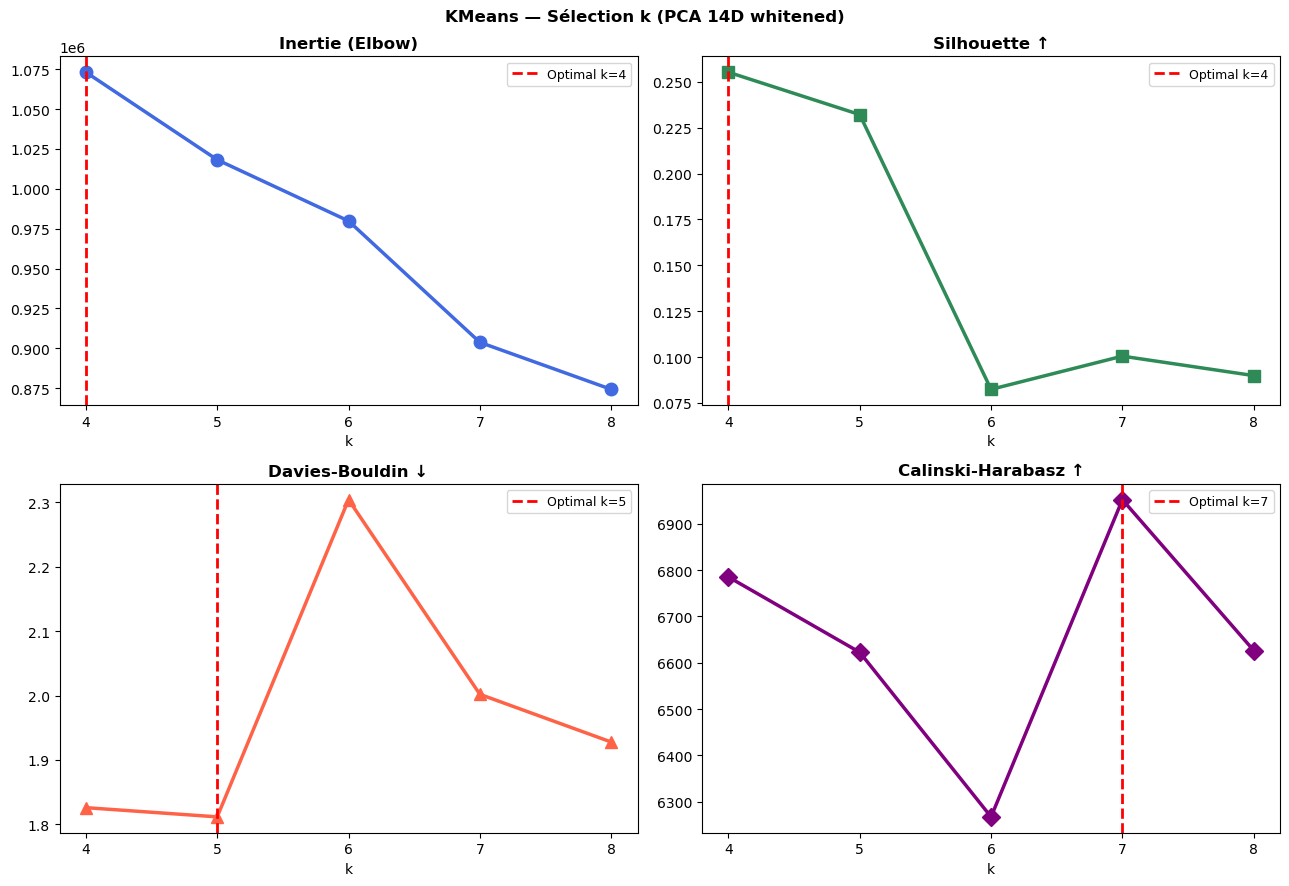

CPU times: total: 1min 20s
Wall time: 26 s


In [11]:
%%time
print("=" * 60)
print("  ALGO 1 : KMeans — Elbow & sélection k optimal")
print("=" * 60)

inertias, sils_km, dbs_km, chs_km = [], [], [], []

for k in K_RANGE:
    t0  = time.time()
    km  = MiniBatchKMeans(n_clusters=k, batch_size=4096,
                           n_init=10, max_iter=300,
                           random_state=RANDOM_STATE)
    lbs = km.fit_predict(X_pca)
    m   = evaluate_clustering(X_pca, lbs)
    inertias.append(km.inertia_)
    sils_km.append(m["silhouette"])
    dbs_km.append(m["davies_bouldin"])
    chs_km.append(m["calinski_harabasz"])
    print(f"  k={k} | sil={m['silhouette']:.4f} | "
          f"db={m['davies_bouldin']:.4f} | "
          f"ch={m['calinski_harabasz']:>8.0f} | {time.time()-t0:.1f}s")
    del lbs; gc.collect()

kl    = KneeLocator(list(K_RANGE), inertias,
                    curve="convex", direction="decreasing")
K_OPT = kl.knee or K_MIN
print(f"\n→ k optimal (KneeLocator) : {K_OPT}")

# Elbow plots
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_f = axes.flatten()
for ax, data, label, color, marker in zip(
    axes_f,
    [inertias, sils_km, dbs_km, chs_km],
    ["Inertie (Elbow)", "Silhouette ↑",
     "Davies-Bouldin ↓", "Calinski-Harabasz ↑"],
    ["royalblue", "seagreen", "tomato", "purple"],
    ["o", "s", "^", "D"]
):
    ax.plot(K_RANGE, data, color=color, marker=marker, lw=2.5, ms=9)
    if "↑" in label:
        best_k = list(K_RANGE)[np.argmax(data)]
    elif "↓" in label:
        best_k = list(K_RANGE)[np.argmin(data)]
    else:
        best_k = K_OPT
    ax.axvline(best_k, color="red", ls="--", lw=2,
               label=f"Optimal k={best_k}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("k"); ax.set_xticks(list(K_RANGE))
    ax.legend(fontsize=9)

plt.suptitle(f"KMeans — Sélection k (PCA {N_COMP}D whitened)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("figures/02_kmeans_elbow.png", bbox_inches="tight", dpi=100)
plt.show(); plt.close()

KMeans — k de 4 à 8 | meilleur parmi 3 seeds...
  ✔ KMeans_k4                                               | k=4 | sil=0.2522 | db=1.8263
  k=4 | C0:8,316, C1:7,143, C2:74,197, C3:3,702
  ✔ KMeans_k5                                               | k=5 | sil=0.2393 | db=1.8105
  k=5 | C0:7,220, C1:6,985, C2:68,152, C3:3,686, C4:7,315
  ✔ KMeans_k6                                               | k=6 | sil=0.0873 | db=2.4217
  k=6 | C0:7,964, C1:34,218, C2:10,128, C3:7,358, C4:21,512, C5:12,178
  ✔ KMeans_k7                                               | k=7 | sil=0.1076 | db=1.8893
  k=7 | C0:26,124, C1:3,255, C2:14,879, C3:39,617, C4:1,350, C5:916, C6:7,217
  ✔ KMeans_k8                                               | k=8 | sil=0.0960 | db=1.9562
  k=8 | C0:6,949, C1:28,951, C2:5,513, C3:1,504, C4:2,778, C5:3,327, C6:32,796, C7:11,540

→ k optimal KMeans (silhouette) : 4


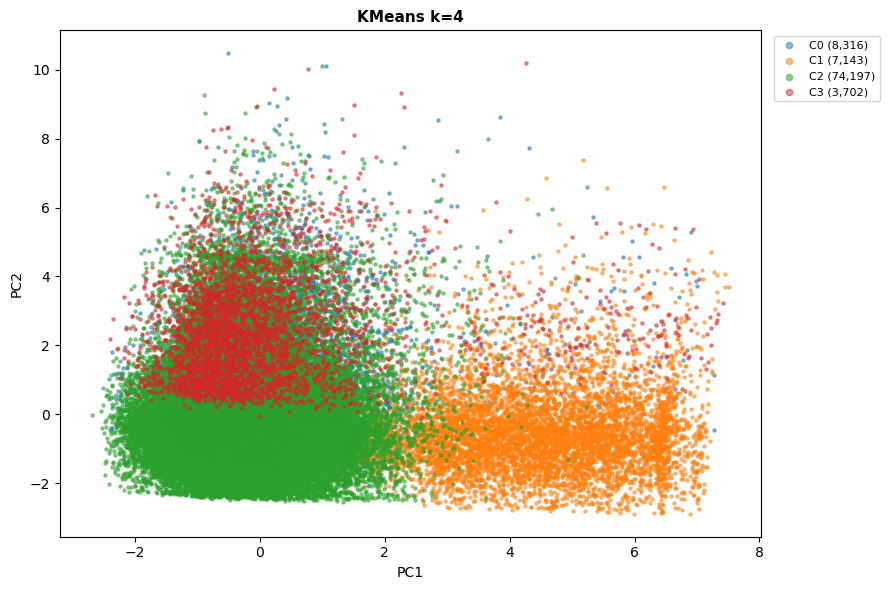

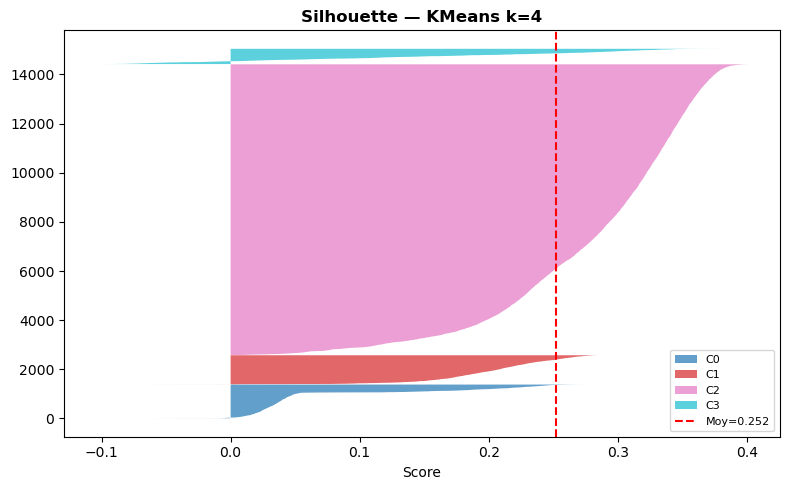

CPU times: total: 5min 11s
Wall time: 1min 41s


In [12]:
%%time
KM_MODELS = {}
print(f"KMeans — k de {K_MIN} à {K_MAX} | meilleur parmi 3 seeds...")

for k in K_RANGE:
    best_sil = -1; best_mod = None; best_lbs = None
    for seed in [42, 123, 456]:
        km  = MiniBatchKMeans(n_clusters=k, batch_size=4096,
                               n_init=20, max_iter=500,
                               random_state=seed)
        lbs = km.fit_predict(X_pca)
        m   = evaluate_clustering(X_pca, lbs)
        if m["silhouette"] > best_sil:
            best_sil = m["silhouette"]
            best_mod = km
            best_lbs = lbs.copy()
        del lbs; gc.collect()

    m_best = evaluate_clustering(X_pca, best_lbs)
    rn     = f"KMeans_k{k}"
    rid    = log_run(rn, "KMeans", {"k": k, "n_pca": N_COMP},
                     m_best, best_mod, scaler,
                     FEATURES_ACTIVE, pca_obj=pca_final, n_comp=N_COMP)
    register(rn, "KMeans", k, m_best, rid)
    KM_MODELS[k] = {"model": best_mod, "labels": best_lbs.copy(),
                    "metrics": m_best}
    dist  = pd.Series(best_lbs).value_counts().sort_index()
    sizes = ", ".join([f"C{c}:{n:,}" for c, n in dist.items()])
    print(f"  k={k} | {sizes}")
    del best_lbs; gc.collect()

K_OPT_KM = max(KM_MODELS,
               key=lambda k: KM_MODELS[k]["metrics"]["silhouette"])
print(f"\n→ k optimal KMeans (silhouette) : {K_OPT_KM}")

plot_pca_clusters(X_pca_2d, KM_MODELS[K_OPT_KM]["labels"],
                  f"KMeans k={K_OPT_KM}",
                  save=f"figures/03_kmeans_k{K_OPT_KM}.png")
plot_silhouette(X_pca, KM_MODELS[K_OPT_KM]["labels"],
                f"KMeans k={K_OPT_KM}")

  ALGO 2 : CAH Ward (sous-échantillon 20,000)


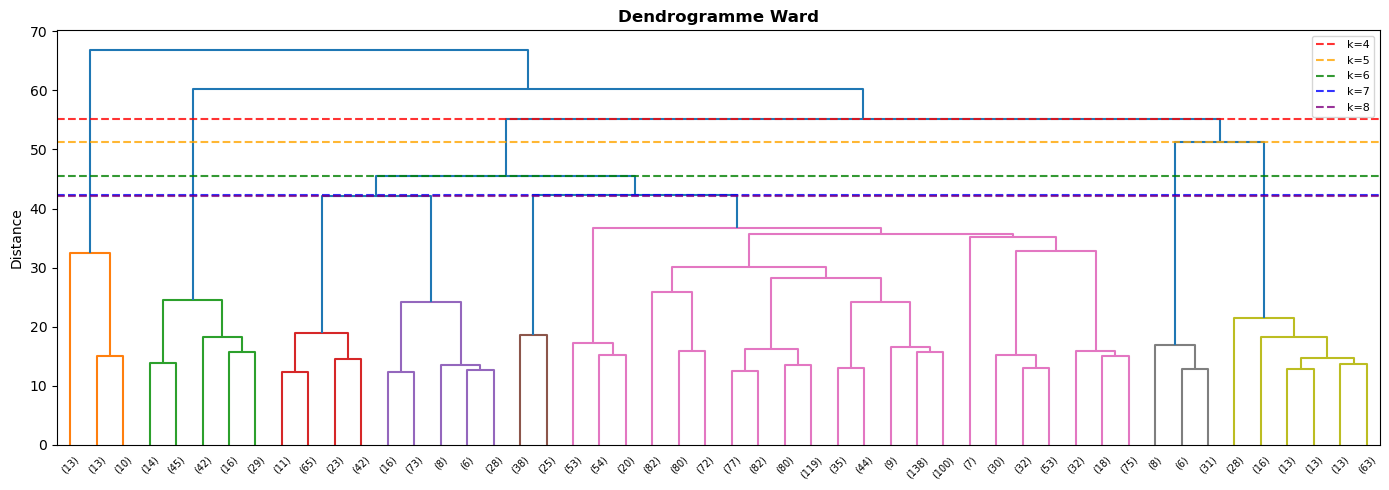

  ✔ CAH_k4                                                  | k=4 | sil=0.2270 | db=1.6781
  k=4 | C0:16,830, C1:323, C2:1,418, C3:1,429
  ✔ CAH_k5                                                  | k=5 | sil=0.2407 | db=1.5726
  k=5 | C0:16,354, C1:323, C2:1,418, C3:1,429, C4:476
  ✔ CAH_k6                                                  | k=6 | sil=0.2436 | db=1.4631
  k=6 | C0:16,149, C1:323, C2:1,418, C3:1,429, C4:476, C5:205
  ✔ CAH_k7                                                  | k=7 | sil=0.2454 | db=1.4626
  k=7 | C0:15,378, C1:323, C2:1,418, C3:1,429, C4:476, C5:205, C6:771
  ✔ CAH_k8                                                  | k=8 | sil=0.1885 | db=1.5345
  k=8 | C0:13,758, C1:323, C2:1,418, C3:1,429, C4:476, C5:205, C6:771, C7:1,620

→ k optimal CAH : 7


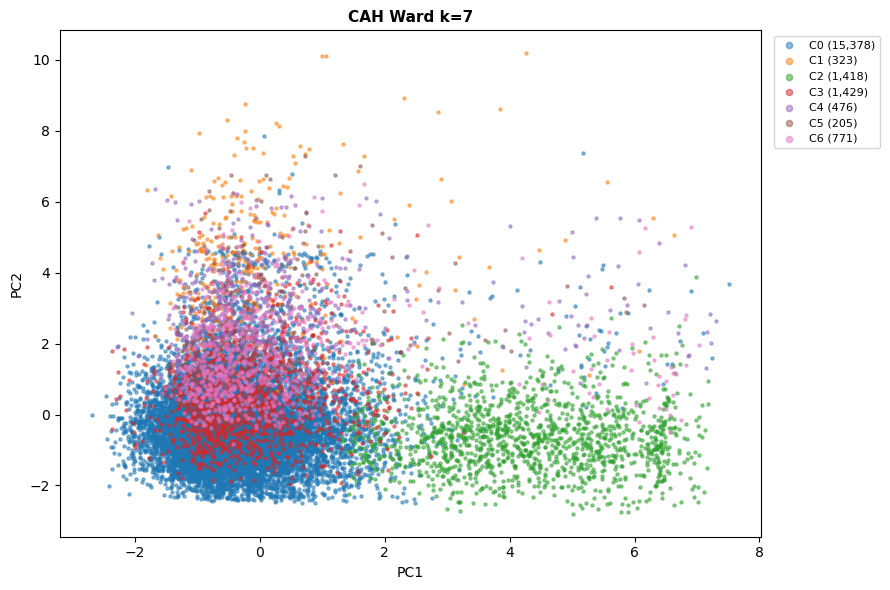

CPU times: total: 2min 52s
Wall time: 2min 5s


4829

In [13]:
%%time
print("=" * 60)
print(f"  ALGO 2 : CAH Ward (sous-échantillon {N_SLOW:,})")
print("=" * 60)

rng_cah = np.random.default_rng(RANDOM_STATE + 10)
idx_cah = rng_cah.choice(len(X_pca), N_SLOW, replace=False)
X_cah   = X_pca[idx_cah].copy()

# Dendrogramme
idx_d = rng_cah.choice(N_SLOW, 2_000, replace=False)
Z     = linkage(X_cah[idx_d], method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=50,
           leaf_rotation=45, leaf_font_size=7,
           color_threshold=0.6 * max(Z[:, 2]))
heights = sorted(Z[:, 2], reverse=True)
colors_cut = ["red","orange","green","blue","purple"]
for i_k, k_l in enumerate(K_RANGE):
    if k_l - 2 < len(heights):
        ax.axhline(heights[k_l-2], color=colors_cut[i_k % 5],
                   ls="--", lw=1.5, alpha=0.8, label=f"k={k_l}")
ax.set_title("Dendrogramme Ward", fontweight="bold")
ax.set_ylabel("Distance"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/04_dendrogramme.png", bbox_inches="tight", dpi=100)
plt.show(); plt.close()
del Z; gc.collect()

CAH_MODELS = {}
for k in K_RANGE:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    lbs = agg.fit_predict(X_cah)
    m   = evaluate_clustering(X_cah, lbs)
    rn  = f"CAH_k{k}"
    rid = log_run(rn, "CAH_ward",
                  {"k": k, "n_pca": N_COMP, "n_sample": N_SLOW},
                  m, agg, scaler, FEATURES_ACTIVE,
                  pca_obj=pca_final, n_comp=N_COMP)
    register(rn, "CAH_ward", k, m, rid)
    CAH_MODELS[k] = {"model": agg, "labels": lbs.copy(),
                     "idx": idx_cah, "metrics": m}
    dist  = pd.Series(lbs).value_counts().sort_index()
    sizes = ", ".join([f"C{c}:{n:,}" for c, n in dist.items()])
    print(f"  k={k} | {sizes}")
    del lbs; gc.collect()

K_OPT_CAH = max(CAH_MODELS,
                key=lambda k: CAH_MODELS[k]["metrics"]["silhouette"])
print(f"\n→ k optimal CAH : {K_OPT_CAH}")
plot_pca_clusters(X_pca_2d[idx_cah],
                  CAH_MODELS[K_OPT_CAH]["labels"],
                  f"CAH Ward k={K_OPT_CAH}",
                  save=f"figures/05_cah_k{K_OPT_CAH}.png")
del X_cah; gc.collect()

  ALGO 3 : DBSCAN (sous-échantillon stratifié 15,000)
Échantillon : 14,994 (9 strates)


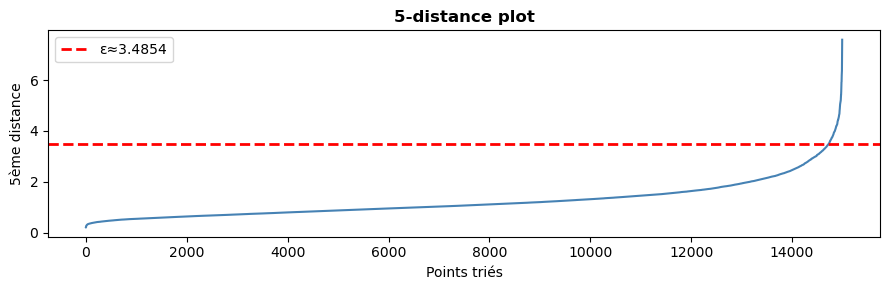

ε optimal : 3.4854

Grid DBSCAN : 45 configs | Filtre 4≤k≤8
  ✔ DBSCAN_eps2.0912_ms8                                    | k=7 | sil=0.1673 | db=1.2195
  ✔ DBSCAN_eps2.0912_ms10                                   | k=7 | sil=0.1583 | db=1.2684
  ✔ DBSCAN_eps2.0912_ms15                                   | k=4 | sil=0.2546 | db=1.2285
  ✔ DBSCAN_eps2.4398_ms8                                    | k=8 | sil=0.1215 | db=1.0518
  ✔ DBSCAN_eps2.4398_ms10                                   | k=8 | sil=0.1331 | db=1.2745
  ✔ DBSCAN_eps2.4398_ms15                                   | k=5 | sil=0.1303 | db=1.3051
  ✔ DBSCAN_eps2.7883_ms8                                    | k=7 | sil=0.4267 | db=1.0405
  ✔ DBSCAN_eps2.7883_ms10                                   | k=7 | sil=0.4339 | db=1.0159
  ✔ DBSCAN_eps2.7883_ms15                                   | k=5 | sil=0.1438 | db=1.1748
  ✔ DBSCAN_eps3.4854_ms20                                   | k=4 | sil=0.5555 | db=0.6158

→ Meilleur DBSCAN : eps=3.485

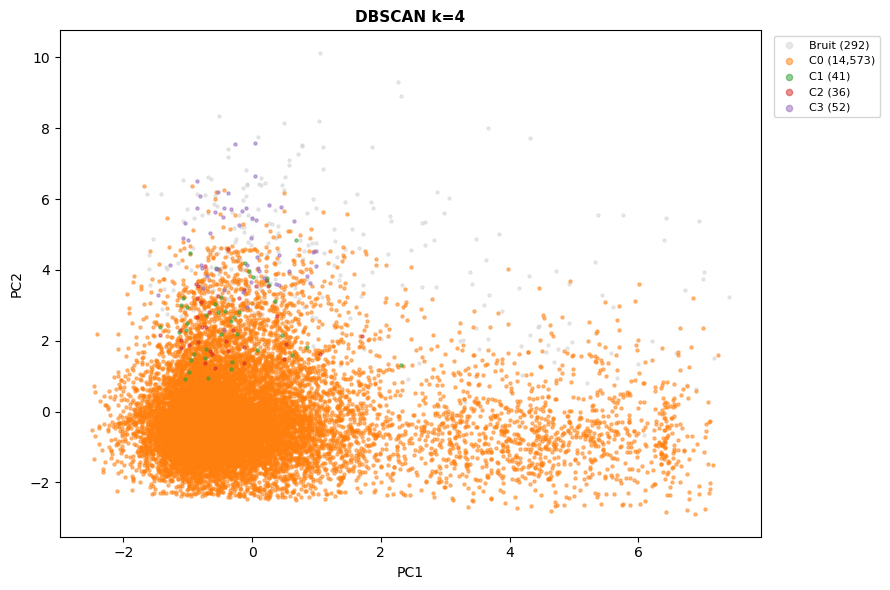

CPU times: total: 21min 30s
Wall time: 4min 42s


4228

In [14]:
%%time
print("=" * 60)
print(f"  ALGO 3 : DBSCAN (sous-échantillon stratifié {N_DBSCAN:,})")
print("=" * 60)

# Sous-échantillon stratifié sur Recency + Monetary
df_tmp = df_client[["Recency","Monetary_log"]].copy() if "Monetary_log" in df_client.columns \
         else df_client[["Recency","Monetary"]].copy()
df_tmp["strate"] = (
    pd.qcut(df_tmp.iloc[:,0], q=3, labels=False).astype(str) + "_" +
    pd.qcut(df_tmp.iloc[:,1].clip(upper=df_tmp.iloc[:,1].quantile(0.99)),
            q=3, labels=False, duplicates="drop").astype(str)
)
n_strates    = df_tmp["strate"].nunique()
n_par_strate = max(1, N_DBSCAN // n_strates)
idx_parts    = []
for strate, grp in df_tmp.groupby("strate"):
    idx_parts.extend(np.random.choice(grp.index.tolist(),
                     min(n_par_strate, len(grp)), replace=False))
idx_dbs = np.array(idx_parts[:N_DBSCAN])
X_dbs   = X_pca[idx_dbs].copy()
del df_tmp; gc.collect()
print(f"Échantillon : {len(X_dbs):,} ({n_strates} strates)")

# k-distance plot
nbrs     = NearestNeighbors(n_neighbors=5, n_jobs=-1).fit(X_dbs)
dist5, _ = nbrs.kneighbors(X_dbs)
d_sorted = np.sort(dist5[:, 4])
kl_e     = KneeLocator(range(len(d_sorted)), d_sorted,
                        curve="convex", direction="increasing")
EPS      = float(d_sorted[kl_e.knee]) if kl_e.knee \
           else float(np.percentile(d_sorted, 85))
del nbrs, dist5; gc.collect()

plt.figure(figsize=(9, 3))
plt.plot(d_sorted, lw=1.5, color="steelblue")
plt.axhline(EPS, color="red", ls="--", lw=2, label=f"ε≈{EPS:.4f}")
plt.title("5-distance plot", fontweight="bold")
plt.xlabel("Points triés"); plt.ylabel("5ème distance"); plt.legend()
plt.tight_layout()
plt.savefig("figures/06_dbscan_eps.png", bbox_inches="tight", dpi=100)
plt.show(); plt.close()
del d_sorted
print(f"ε optimal : {EPS:.4f}")

MAX_NOISE = int(len(X_dbs) * 0.12)
grid      = [(round(EPS*r, 4), ms)
             for r in [0.3,0.4,0.5,0.6,0.7,0.8,1.0,1.3,1.6]
             for ms in [5, 8, 10, 15, 20]]

best_dbs = {"sil": -1, "labels": None}
print(f"\nGrid DBSCAN : {len(grid)} configs | Filtre {K_MIN}≤k≤{K_MAX}")
for eps, ms in grid:
    dbs = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
    lbs = dbs.fit_predict(X_dbs)
    m   = evaluate_clustering(X_dbs, lbs)
    nc, nn, sil = m["n_clusters"], m["n_noise"], m["silhouette"]
    if K_MIN <= nc <= K_MAX and nn <= MAX_NOISE and not np.isnan(sil):
        rn  = f"DBSCAN_eps{eps}_ms{ms}"
        rid = log_run(rn, "DBSCAN",
                      {"eps": eps, "min_samples": ms, "n_sample": len(X_dbs)},
                      m, dbs, scaler, FEATURES_ACTIVE,
                      pca_obj=pca_final, n_comp=N_COMP)
        register(rn, "DBSCAN", nc, m, rid)
        if sil > best_dbs["sil"]:
            best_dbs = {"sil": sil, "labels": lbs.copy(),
                        "nc": nc, "eps": eps, "ms": ms}
    del lbs; gc.collect()

if best_dbs["labels"] is not None:
    print(f"\n→ Meilleur DBSCAN : eps={best_dbs['eps']} "
          f"ms={best_dbs['ms']} k={best_dbs['nc']} "
          f"sil={best_dbs['sil']:.4f}")
    plot_pca_clusters(X_pca_2d[idx_dbs], best_dbs["labels"],
                      f"DBSCAN k={best_dbs['nc']}",
                      save="figures/07_dbscan_best.png")
else:
    print(f"\n⚠️  Aucun DBSCAN valide {K_MIN}≤k≤{K_MAX}")
    print("   Normal pour données homogènes (97% one-time buyers)")

del X_dbs; gc.collect()

  ALGO 4 : HDBSCAN (sous-échantillon 15,000)
Grid HDBSCAN : 35 configs | Filtre 4≤k≤8
  ✔ HDBSCAN_mc8_ms10                                        | k=8 | sil=0.1902 | db=1.3006
  ✔ HDBSCAN_mc10_ms10                                       | k=8 | sil=0.1902 | db=1.3006
  ✔ HDBSCAN_mc15_ms8                                        | k=7 | sil=0.2001 | db=1.3401
  ✔ HDBSCAN_mc15_ms10                                       | k=7 | sil=0.1989 | db=1.3090
  ✔ HDBSCAN_mc20_ms5                                        | k=8 | sil=0.1876 | db=1.5345
  ✔ HDBSCAN_mc20_ms8                                        | k=7 | sil=0.2001 | db=1.3401
  ✔ HDBSCAN_mc20_ms10                                       | k=7 | sil=0.1989 | db=1.3090
  ✔ HDBSCAN_mc30_ms3                                        | k=8 | sil=0.1936 | db=1.6374
  ✔ HDBSCAN_mc30_ms5                                        | k=7 | sil=0.1965 | db=1.4292
  ✔ HDBSCAN_mc30_ms8                                        | k=7 | sil=0.2001 | db=1.3401
  ✔ 

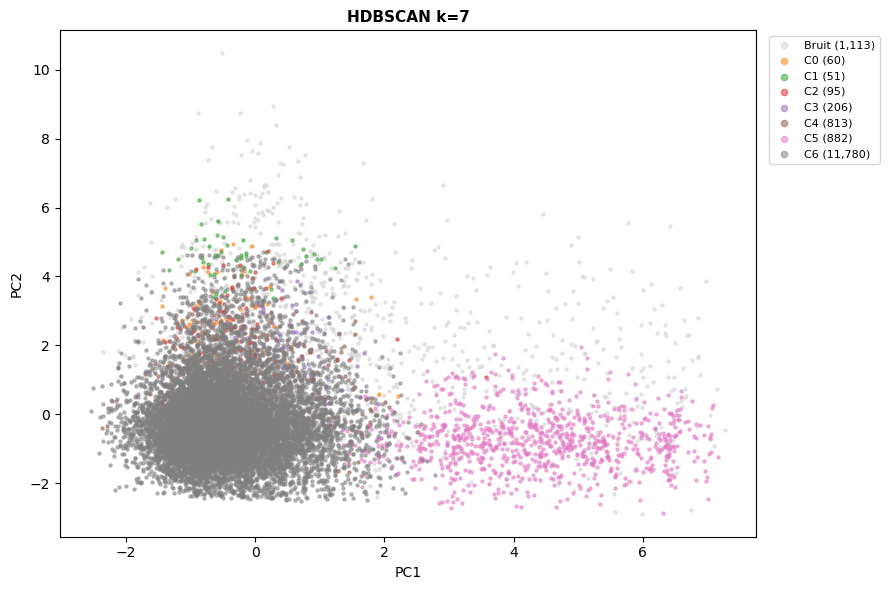

CPU times: total: 11min 45s
Wall time: 25min 41s


4965

In [15]:
%%time
print("=" * 60)
print(f"  ALGO 4 : HDBSCAN (sous-échantillon {N_HDBSCAN:,})")
print("=" * 60)

rng_hdb = np.random.default_rng(RANDOM_STATE + 70)
idx_hdb = rng_hdb.choice(len(X_pca), N_HDBSCAN, replace=False)
X_hdb   = X_pca[idx_hdb].copy()

grid_hdb = [(mc, ms) for mc in [5,8,10,15,20,30,50]
             for ms in [3,5,8,10,15]]

best_hdb = {"sil": -1, "labels": None}
print(f"Grid HDBSCAN : {len(grid_hdb)} configs | Filtre {K_MIN}≤k≤{K_MAX}")

for min_c, min_s in grid_hdb:
    clf = hdbscan.HDBSCAN(min_cluster_size=min_c,
                           min_samples=min_s,
                           metric="euclidean",
                           cluster_selection_method="eom",
                           core_dist_n_jobs=-1)
    lbs = clf.fit_predict(X_hdb)
    m   = evaluate_clustering(X_hdb, lbs)
    nc, nn, sil = m["n_clusters"], m["n_noise"], m["silhouette"]
    if K_MIN <= nc <= K_MAX and nn <= N_HDBSCAN*0.15 and not np.isnan(sil):
        rn  = f"HDBSCAN_mc{min_c}_ms{min_s}"
        rid = log_run(rn, "HDBSCAN",
                      {"min_cluster_size": min_c, "min_samples": min_s,
                       "n_sample": N_HDBSCAN},
                      m, clf, scaler, FEATURES_ACTIVE,
                      pca_obj=pca_final, n_comp=N_COMP)
        register(rn, "HDBSCAN", nc, m, rid)
        if sil > best_hdb["sil"]:
            best_hdb = {"sil": sil, "labels": lbs.copy(),
                        "nc": nc, "mc": min_c, "ms": min_s}
    del lbs; gc.collect()

if best_hdb["labels"] is not None:
    print(f"\n→ Meilleur HDBSCAN : mc={best_hdb['mc']} "
          f"ms={best_hdb['ms']} k={best_hdb['nc']} "
          f"sil={best_hdb['sil']:.4f}")
    plot_pca_clusters(X_pca_2d[idx_hdb], best_hdb["labels"],
                      f"HDBSCAN k={best_hdb['nc']}",
                      save="figures/08_hdbscan_best.png")
else:
    print(f"\n⚠️  Aucun HDBSCAN valide {K_MIN}≤k≤{K_MAX}")

del X_hdb; gc.collect()

Total runs valides : 35

=== Classement par Silhouette ↓ ===

             run_name algorithm  n_clusters  n_noise  silhouette  davies_bouldin  calinski_harabasz
DBSCAN_eps3.4854_ms20    DBSCAN           4      292      0.5555          0.6158             357.61
DBSCAN_eps2.7883_ms10    DBSCAN           7      551      0.4339          1.0159             159.27
 DBSCAN_eps2.7883_ms8    DBSCAN           7      509      0.4267          1.0405             166.57
DBSCAN_eps2.0912_ms15    DBSCAN           4     1585      0.2546          1.2285             518.76
            KMeans_k4    KMeans           4        0      0.2522          1.8263            6785.54
               CAH_k7  CAH_ward           7        0      0.2454          1.4626            1429.45
               CAH_k6  CAH_ward           6        0      0.2436          1.4631            1429.86
               CAH_k5  CAH_ward           5        0      0.2407          1.5726            1431.83
            KMeans_k5    KMeans       

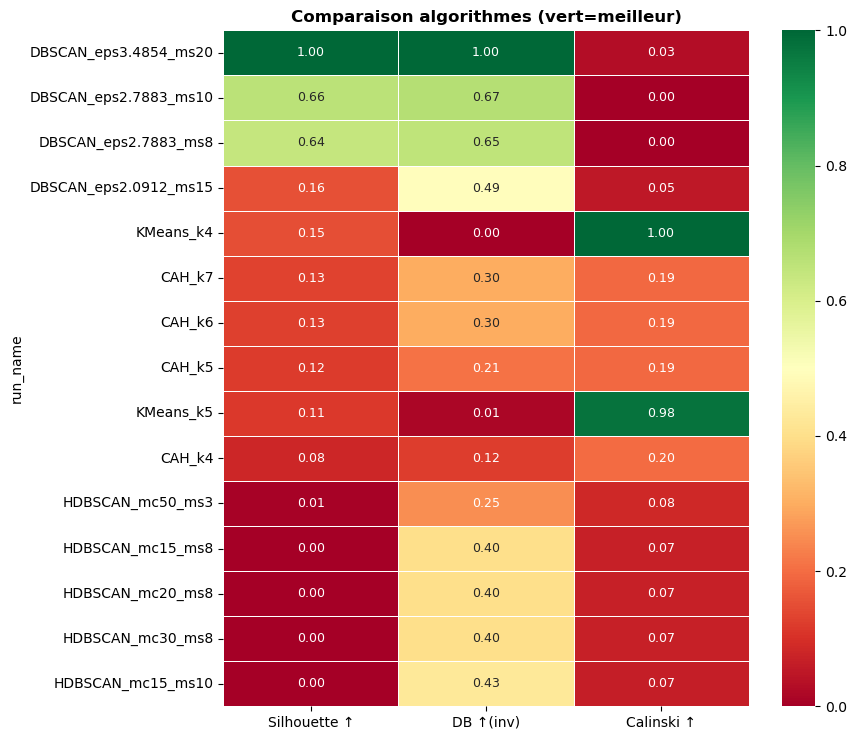

In [16]:
df_comp = (
    pd.DataFrame(ALL_RESULTS)
    .dropna(subset=["silhouette"])
    .query(f"n_clusters >= {K_MIN} and n_clusters <= {K_MAX}")
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)
df_comp.to_csv("reports/clustering_comparison.csv", index=False)
print(f"Total runs valides : {len(df_comp)}")
print("\n=== Classement par Silhouette ↓ ===\n")
print(df_comp[["run_name","algorithm","n_clusters","n_noise",
               "silhouette","davies_bouldin",
               "calinski_harabasz"]].to_string(index=False))

# Score composite
df_sc = df_comp.copy()
for col, w, inv in [("silhouette",0.5,False),
                     ("davies_bouldin",0.3,True),
                     ("calinski_harabasz",0.2,False)]:
    r = df_sc[col].max() - df_sc[col].min() + 1e-9
    n = (df_sc[col] - df_sc[col].min()) / r
    df_sc[col+"_w"] = (1-n if inv else n) * w
df_sc["score"] = (df_sc["silhouette_w"] +
                  df_sc["davies_bouldin_w"] +
                  df_sc["calinski_harabasz_w"])
df_sc = df_sc.sort_values("score", ascending=False)

print("\n=== TOP 10 Score composite ===\n")
print(df_sc[["run_name","algorithm","n_clusters",
             "silhouette","davies_bouldin","score"]
           ].head(10).round(4).to_string(index=False))

BEST    = df_sc.iloc[0]
K_FINAL = int(BEST["n_clusters"])
print(f"\n🏆 MEILLEUR : {BEST['run_name']}")
print(f"   k={K_FINAL} | sil={BEST['silhouette']:.4f} "
      f"| db={BEST['davies_bouldin']:.4f} "
      f"| score={BEST['score']:.4f}")

# Heatmap
top = df_comp.head(15).copy()
for col in ["silhouette","davies_bouldin","calinski_harabasz"]:
    r = top[col].max() - top[col].min() + 1e-9
    top[col+"_n"] = (top[col] - top[col].min()) / r
top["davies_bouldin_n"] = 1 - top["davies_bouldin_n"]
hm = top.set_index("run_name")[["silhouette_n",
                                  "davies_bouldin_n",
                                  "calinski_harabasz_n"]]
hm.columns = ["Silhouette ↑","DB ↑(inv)","Calinski ↑"]
plt.figure(figsize=(9, max(5, len(top)*0.5)))
sns.heatmap(hm, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, lw=0.4, annot_kws={"size":9})
plt.title("Comparaison algorithmes (vert=meilleur)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/09_heatmap_comparaison.png",
            bbox_inches="tight", dpi=100)
plt.show(); plt.close()

Modèle : k=4
  C 0 |   8,316 (  8.9%) █████
  C 1 |   7,143 (  7.7%) ████
  C 2 |  74,197 ( 79.5%) ███████████████████████████████████████████████
  C 3 |   3,702 (  4.0%) ██

=== Profil MÉDIAN par cluster ===
         Recency  Monetary  avg_review_score_available  avg_delivery_days  avg_installments  avg_freight_ratio  dist_sao_paulo  avg_basket_size  late_delivery_rate
cluster                                                                                                                                                            
0          272.0    171.68                         4.0                9.0               2.0               0.22          350.27              2.0                 0.0
1          238.0    108.42                         2.0               29.0               2.0               0.19          381.94              1.0                 1.0
2          272.0     96.95                         5.0                9.0               1.0               0.19          353.48        

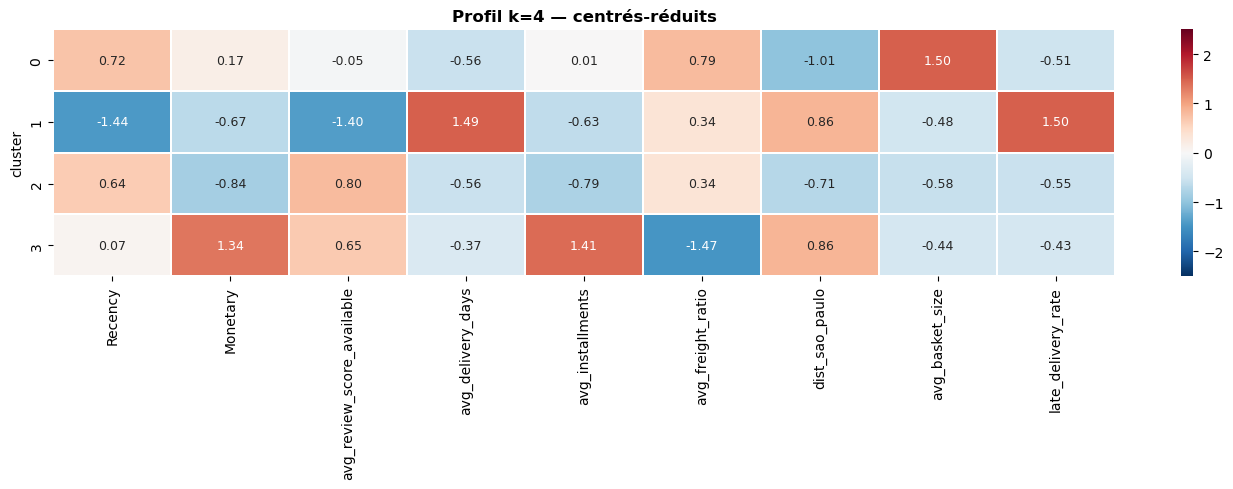

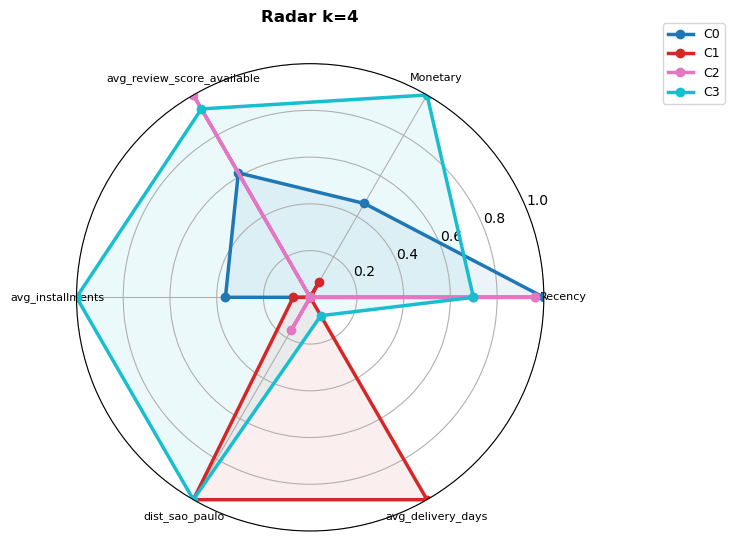

In [17]:
# ── Récupérer les labels du meilleur modèle ──────────────────
if "KMeans" in BEST["algorithm"] and K_FINAL in KM_MODELS:
    labels_final = KM_MODELS[K_FINAL]["labels"]
    model_final  = KM_MODELS[K_FINAL]["model"]
elif "CAH" in BEST["algorithm"] and K_FINAL in CAH_MODELS:
    labels_final = CAH_MODELS[K_FINAL]["labels"]
    model_final  = CAH_MODELS[K_FINAL]["model"]
else:
    labels_final = KM_MODELS[K_OPT_KM]["labels"]
    model_final  = KM_MODELS[K_OPT_KM]["model"]
    K_FINAL      = K_OPT_KM

df_client["cluster"] = labels_final
df_clean = df_client[df_client["cluster"] != -1].copy()

print(f"Modèle : k={K_FINAL}")
for cid, n in df_client["cluster"].value_counts().sort_index().items():
    bar = "█" * int(n/len(df_client)*60)
    print(f"  C{cid:>2} | {n:>7,} ({n/len(df_client)*100:5.1f}%) {bar}")

PROFILE_COLS = [
    "Recency","Monetary","avg_review_score_available",
    "avg_delivery_days","avg_installments","avg_freight_ratio",
    "dist_sao_paulo","avg_basket_size","late_delivery_rate",
]
# Garder uniquement les colonnes disponibles
PROFILE_COLS = [c for c in PROFILE_COLS if c in df_clean.columns]

profile_med  = df_clean.groupby("cluster")[PROFILE_COLS].median().round(2)
profile_mean = df_clean.groupby("cluster")[PROFILE_COLS].mean().round(2)
profile_med.to_csv("reports/cluster_profiles_median.csv")
profile_mean.to_csv("reports/cluster_profiles_mean.csv")

print("\n=== Profil MÉDIAN par cluster ===")
print(profile_med.to_string())

# Heatmap profil centré-réduit
prof_norm = (profile_mean - profile_mean.mean()) / (profile_mean.std() + 1e-9)
fig, ax   = plt.subplots(figsize=(14, max(5, K_FINAL*0.9)))
sns.heatmap(prof_norm, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-2.5, vmax=2.5, lw=0.3, annot_kws={"size": 9}, ax=ax)
ax.set_title(f"Profil k={K_FINAL} — centrés-réduits",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(f"figures/10_profil_k{K_FINAL}.png",
            bbox_inches="tight", dpi=100)
plt.show(); plt.close()

radar_chart(
    profile_mean[[c for c in ["Recency","Monetary",
                               "avg_review_score_available",
                               "avg_installments","dist_sao_paulo",
                               "avg_delivery_days"] if c in profile_mean.columns]],
    title=f"Radar k={K_FINAL}",
    save=f"figures/11_radar_k{K_FINAL}.png"
)

In [18]:
rec_q   = df_clean["Recency"].quantile([0.25,0.50,0.75]).values
mon_q   = df_clean["Monetary"].quantile([0.25,0.50,0.75]).values
rev_med = df_clean["avg_review_score_available"].median()
ins_q75 = df_clean["avg_installments"].quantile(0.75)
del_q25 = df_clean["avg_delivery_days"].quantile(0.25)
del_med = df_clean["avg_delivery_days"].median()

print(f"Seuils Recency  : Q25={rec_q[0]:.0f}j  Q75={rec_q[2]:.0f}j")
print(f"Seuils Monetary : Q25={mon_q[0]:.0f}  Q75={mon_q[2]:.0f} BRL")
print(f"Délai Q25={del_q25:.0f}j  med={del_med:.0f}j | Review med={rev_med:.1f}")


def name_segment(row):
    r, m = row["Recency"], row["Monetary"]
    rev  = row["avg_review_score_available"]
    ins  = row["avg_installments"]
    d    = row["avg_delivery_days"]

    # Priorité 1 : insatisfaction
    if rev <= 2:
        return "😡 Clients Déçus"
    # Priorité 2 : récents
    if r <= rec_q[0]:
        return "🌟 Clients Récents Actifs"
    # Priorité 3 : premium crédit
    if ins >= ins_q75 and m >= mon_q[1]:
        return "💎 Premium Crédit"
    # Priorité 4 : livraison rapide petits paniers
    if d <= del_q25 and m <= mon_q[1]:
        return "⚡ Petits Acheteurs Rapides"
    # Priorité 5 : bon panier
    if m >= mon_q[1]:
        return "🛍️ Acheteurs Valeur Moyenne"
    # Priorité 6
    return "😴 Dormants Faible Valeur"


SEGMENT_ACTIONS = {
    "😡 Clients Déçus":
        "Contact immédiat + bon remboursement + enquête qualité",
    "🌟 Clients Récents Actifs":
        "Programme fidélisation + cross-sell + 2e achat -15%",
    "💎 Premium Crédit":
        "Offres VIP + augmentation plafond crédit + early access",
    "⚡ Petits Acheteurs Rapides":
        "Upsell catégories premium + notification nouveautés",
    "🛍️ Acheteurs Valeur Moyenne":
        "Réactivation + offre bundle + programme points",
    "😴 Dormants Faible Valeur":
        "Campagne win-back -20% ou désengagement progressif",
}

profile_med["segment"] = profile_med.apply(name_segment, axis=1)
SEGMENT_NAMES = profile_med["segment"].to_dict()

# Vérification unicité
unique_names = set(SEGMENT_NAMES.values())
if len(unique_names) < len(SEGMENT_NAMES):
    print("⚠️  Noms dupliqués — ajustez les seuils de name_segment")
    for cid, name in SEGMENT_NAMES.items():
        if list(SEGMENT_NAMES.values()).count(name) > 1:
            print(f"  C{cid} → '{name}' dupliqué")
else:
    print("✅ Tous les clusters ont un nom unique")

print(f"\n{'='*65}")
print(f"  SEGMENTATION FINALE — k={K_FINAL}")
print(f"{'='*65}")
for cid, sname in SEGMENT_NAMES.items():
    n   = (df_client["cluster"] == cid).sum()
    pct = n / len(df_client) * 100
    bar = "█" * int(pct * 2.5)
    row = profile_med.loc[cid]
    print(f"\n  C{cid} — {sname}")
    print(f"  Clients : {n:,} ({pct:.1f}%) {bar}")
    print(f"  Recency={row['Recency']:.0f}j | "
          f"Monetary={row['Monetary']:.0f}BRL | "
          f"Review={row['avg_review_score_available']:.1f}/5 | "
          f"Install={row['avg_installments']:.1f}")
    print(f"  ➡  {SEGMENT_ACTIONS.get(sname, 'Standard')}")

df_client["segment"] = df_client["cluster"].map(SEGMENT_NAMES)
df_client["action"]  = df_client["cluster"].map(
    {k: SEGMENT_ACTIONS.get(v,"Standard")
     for k, v in SEGMENT_NAMES.items()})

df_client[["customer_unique_id","cluster","segment","action"]].to_csv(
    "reports/segmentation_finale.csv", index=False)
print(f"\n✅ reports/segmentation_finale.csv — {len(df_client):,} lignes")
print(f"✅ reports/clustering_comparison.csv")
print(f"✅ reports/cluster_profiles_median.csv")

Seuils Recency  : Q25=164j  Q75=395j
Seuils Monetary : Q25=63  Q75=183 BRL
Délai Q25=6j  med=10j | Review med=5.0
✅ Tous les clusters ont un nom unique

  SEGMENTATION FINALE — k=4

  C0 — 🛍️ Acheteurs Valeur Moyenne
  Clients : 8,316 (8.9%) ██████████████████████
  Recency=272j | Monetary=172BRL | Review=4.0/5 | Install=2.0
  ➡  Réactivation + offre bundle + programme points

  C1 — 😡 Clients Déçus
  Clients : 7,143 (7.7%) ███████████████████
  Recency=238j | Monetary=108BRL | Review=2.0/5 | Install=2.0
  ➡  Contact immédiat + bon remboursement + enquête qualité

  C2 — 😴 Dormants Faible Valeur
  Clients : 74,197 (79.5%) ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Recency=272j | Monetary=97BRL | Review=5.0/5 | Install=1.0
  ➡  Campagne win-back -20% ou désengagement progressif

  C3 — 💎 Premium Crédit
  Clients : 3,702 (4.0%) ████